In [24]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [13]:
from pathlib import Path

# running this from inside the 'zoneomics' directory
root = Path('../../../data/zoneomics/')

all_dfs = []

for state_dir in root.iterdir():
    if state_dir.is_dir():
        state = state_dir.name
        for csv_file in state_dir.glob('*.csv'):
            city = csv_file.stem  # Removes the .csv extension to get the city name
            df = pd.read_csv(csv_file)
            df.insert(0, 'state', state)
            df.insert(0, 'city', city)
            all_dfs.append(df)

if all_dfs:
    master_df = pd.concat(all_dfs, ignore_index=True)
    print("Done!")
    # master_df.to_csv('combined_zoning.csv', index=False)
    # print("Combined CSV saved to 'combined_zoning.csv'")
else:
    print("No CSV files found.")

Done!


In [14]:
master_df

,city,state,zone_code,zone_subtype,area_acres,description
0,springfield,missouri,CC,Center City,354.22,NaN
1,springfield,missouri,COM-1,Commercial Street Zone 1,19.97,NaN
2,springfield,missouri,COM-2,Commercial Street Zone 2,13.92,NaN
3,springfield,missouri,CS,Commercial Service,226.97,NaN
4,springfield,missouri,GAP-A,Grant Avenue Parkway Subdistrict A,7.53,NaN
...,...,...,...,...,...,...
187742,watsonville,california,PF,Public Facilities,370.38,The purpose of the public facilities PF distri...
187743,watsonville,california,R-1,Single Family Residential Low Density,529.19,The purpose of the single family residential l...
187744,watsonville,california,R-1P,Planned Single Family Residential,97.27,The purpose of the single family planned resid...
187745,watsonville,california,RM-2,Multiple Residential Medium Density,554.07,The purpose of the multiple residential distri...


In [15]:
len(np.unique(master_df.city))

9905

In [16]:
master_df.dtypes

city               str
state              str
zone_code       object
zone_subtype    object
area_acres      object
description     object
dtype: object

In [ ]:
# fix data types
master_df['zone_code'] = master_df['zone_code'].astype(str)
master_df['zone_subtype'] = master_df['zone_subtype'].astype(str)

# drop rows with missing zone_code
master_df.dropna(subset=['zone_code'], inplace=True)
master_df.reset_index(drop=True, inplace=True)

In [ ]:
# add a column for the length of the zone_code
master_df['len_code'] = master_df['zone_code'].apply(lambda x: len(x))
master_df.len_code.describe()

count    187743.000000
mean          5.112255
std           8.799890
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max          90.000000
Name: len_code, dtype: float64

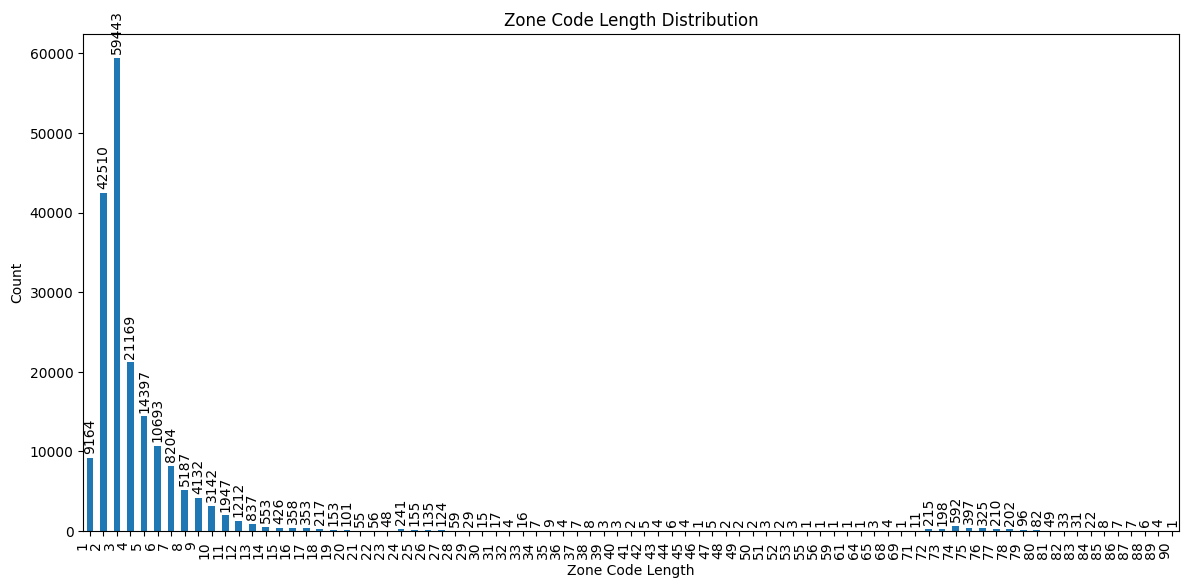

In [92]:
value_counts = master_df.len_code.value_counts()
value_counts.sort_index(inplace=True)

value_counts.plot(kind='bar', figsize=(12,6))
plt.bar_label(plt.gca().containers[0], padding=3, rotation=90)
plt.xticks(rotation=90, ha='right')
plt.xlabel('Zone Code Length')
plt.ylabel('Count')
plt.title('Zone Code Length Distribution')
plt.tight_layout()
plt.show()

In [93]:
def get_random_long_codes(df, min_length, n):
    filtered = df[df['len_code'] > min_length]
    if filtered.empty:
        return pd.DataFrame()
    return filtered.sample(n=min(n, len(filtered)), random_state=None).reset_index(drop=True)


get_random_long_codes(master_df, min_length=20, n=15)

,city,state,zone_code,zone_subtype,area_acres,description,len_code
0,montgomery-county-unincorporated,maryland,CRT-2.25-C-1.5-R-0.75-H-70,Commercial Residential Town,1.07,NaN,26
1,boston,massachusetts,Art42B_CHARLESTOWN MARITIME ECONOMY RESERVE,Maritime Economy Reserve,222.03,NaN,43
2,boston,massachusetts,ArtUnderlying Zoning_H-3-65,Apartment Residential,141.34,NaN,27
3,san-francisco,california,NCT-UPPER-MARKET-65-B,Upper Market Neighborhood Commercial Transit,3.17,NaN,21
4,san-diego-county-unincorporated,california,S92-AR(L)-D(-)-LOT(2AC)-BT(C)-MFAR(-)-FAR(-)-H...,General Rural,9.64,NaN,74
5,montgomery-county-unincorporated,maryland,CRT-1.0-C-0.75-R-0.25-H-45,Commercial Residential Town,11.6,NaN,26
6,san-diego-county-unincorporated,california,S90-AR(A)-D(.05)-LOT(20AC)-BT(B)-MFAR(-)-FAR(-...,Holding Area,28.92,NaN,77
7,montgomery-county-unincorporated,maryland,CR-1.0-C-0.75-R-0.75-H-60-T,Commercial Residential,14.88,NaN,27
8,san-diego-county-unincorporated,california,S80-AR(M)-D(-)-LOT(2AC)-BT(W)-MFAR(-)-FAR(-)-H...,Open Space,119.51,NaN,79
9,montgomery-county-unincorporated,maryland,CR-6.0-C-6.0-R-6.0-H-175,Commercial Residential,2.0,NaN,24
